In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append(f"./../")
from src.graphs import StaticGraph, DynamicGraph
from qiskit.quantum_info import Statevector, Operator, state_fidelity
from scipy.linalg import expm
import matplotlib.pyplot as plt
import numpy as np

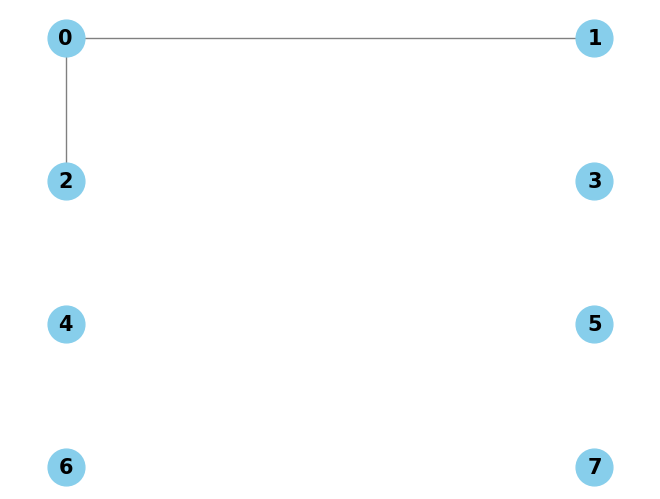

In [2]:
edges = {('000','010'),
         ('000','001')}

G = StaticGraph(edges)
G.draw()

In [3]:
t = 0.3
graph_sequence = [(G, t)]
dyn_G = DynamicGraph(graph_sequence)

In [4]:
psi_0 = Statevector.from_label('0'*G.n_qubits)
print('Initial State: ')
psi_0.draw('latex')

Initial State: 


<IPython.core.display.Latex object>

In [5]:
time_evo_op = dyn_G.time_evo_op()
print('Exact Time Evolution Operator: ')
time_evo_op.draw('latex')

Exact Time Evolution Operator: 


<IPython.core.display.Latex object>

In [6]:
psi_target = psi_0.evolve(time_evo_op)
print('Target (Exact) State: ')
psi_target.draw('latex')

Target (Exact) State: 


<IPython.core.display.Latex object>

In [7]:
edges1 = {('000','010')}

edges2 = {('000','001')}

G1 = StaticGraph(edges1)
G2 = StaticGraph(edges2)

graph_sequence = [(G1, t), (G2, t)]
dyn_G = DynamicGraph(graph_sequence)

In [8]:
time_evo_op = dyn_G.time_evo_op()
print('Approximated Time Evolution Operator: ')
time_evo_op.draw('latex')

Approximated Time Evolution Operator: 


<IPython.core.display.Latex object>

In [9]:
psi_out = psi_0.evolve(time_evo_op)
print('Output (Approximated) State: ')
psi_out.draw('latex')

Output (Approximated) State: 


<IPython.core.display.Latex object>

In [10]:
fid = state_fidelity(psi_out, psi_target)
infid = 1 - fid

print(f'State Infidelity (Difference between Exact State and Approximated State): {round(infid, 3)}')

State Infidelity (Difference between Exact State and Approximated State): 0.0


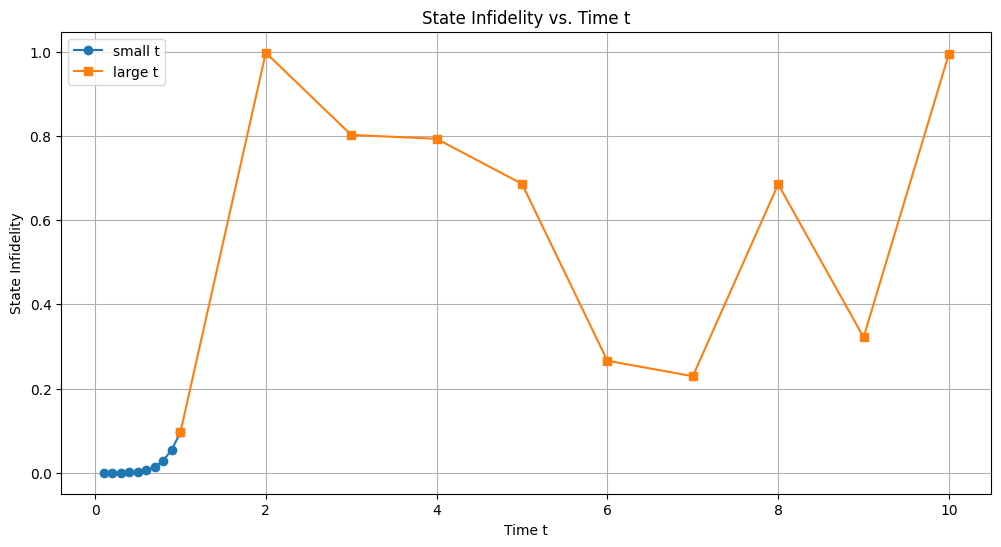

In [11]:
%matplotlib inline

# Function to compute infidelity for a given t
def compute_infidelity(t):
    edges = {('000', '010'), ('000', '001')}
    G = StaticGraph(edges)
    graph_sequence = [(G, t)]
    dyn_G = DynamicGraph(graph_sequence)
    psi_0 = Statevector.from_label('0' * G.n_qubits)
    time_evo_op = dyn_G.time_evo_op()
    psi_target = psi_0.evolve(time_evo_op)

    edges1 = {('000', '010')}
    edges2 = {('000', '001')}
    G1 = StaticGraph(edges1)
    G2 = StaticGraph(edges2)
    graph_sequence = [(G1, t), (G2, t)]
    dyn_G = DynamicGraph(graph_sequence)
    time_evo_op = dyn_G.time_evo_op()
    psi_out = psi_0.evolve(time_evo_op)
    fid = state_fidelity(psi_out, psi_target)
    infid = 1 - fid

    return infid

# Time ranges
t_values_1 = np.arange(0.1, 1.1, 0.1)
t_values_2 = np.arange(1, 11, 1)
infidelities_1 = [compute_infidelity(t) for t in t_values_1]
infidelities_2 = [compute_infidelity(t) for t in t_values_2]

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(t_values_1, infidelities_1, marker='o', label='small t')
plt.plot(t_values_2, infidelities_2, marker='s', label='large t')
plt.xlabel('Time t')
plt.ylabel('State Infidelity')
plt.title('State Infidelity vs. Time t')
plt.legend()
plt.grid(True)
plt.show()